# Q-MAML for the Lipkin-Meshkov-Glick model (nuclear-structure adjacent, not core HEP)

**Scope note, stated up front.** Track J, flagged in this project's own tracks document as worth knowing
about but "not core [HEP]": the LMG model is a nuclear-structure collective-many-body Hamiltonian, not a
particle-physics or gauge-theory system -- included for completeness, not claimed as HEP.

**A naming collision worth being precise about.** Robin & Savage, "Quantum Simulations in Effective Model
Spaces (I): Hamiltonian-Learning VQE ... Application to the Lipkin-Meshkov-Glick Model" (arXiv:2301.05976,
Phys. Rev. C 108, 024313) introduce an algorithm called **HL-VQE** ("Hamiltonian-Learning VQE"). Despite
the name, it does **not** use a classical neural network to predict circuit parameters the way Q-MAML does
-- it iteratively co-optimizes an *effective Hamiltonian* (a single-particle-basis orbital rotation) together
with the variational wavefunction, exploiting non-commuting symmetries and truncations to localize
entanglement into the truncated model space. A genuinely different mechanism aimed at a similar goal. This
notebook does not reimplement HL-VQE's orbital-rotation step; it runs the ordinary Q-MAML Learner-based
approach on the plain (un-rotated) LMG Hamiltonian, their own Eq. 1.

**The Hamiltonian**: $H=\epsilon \hat J_z - \frac{V}{2}(\hat J_+^2+\hat J_-^2)$ in the fully-symmetric
$J=3/2$ collective sector (2 qubits, 4 states) -- matching the source paper's own smallest/showcase scale
directly, not an arbitrary further reduction (their own demonstrations use 1- and 2-qubit effective model
spaces). Task parameters: single-particle splitting $\epsilon$, interaction strength $V$.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_lmg import lmg_hamiltonian, exact_ground_energy, sample_task_space, verify_construction, NUM_QUBITS, J_SPIN
from lmg_qmaml import classical_init, LMGPQC, pretrain_learner_lmg, adapt_task_lmg
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "lmg"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS, f"(J={J_SPIN}, {int(2*J_SPIN+1)} states)")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\lmg
NUM_QUBITS = 2 (J=1.5, 4 states)


## 0. Verify the Hamiltonian construction

Hermiticity; the su(2) algebra relations $[\hat J_z,\hat J_+]=\hat J_+$, $[\hat J_+,\hat J_-]=2\hat J_z$
hold exactly for the constructed generators (a strong, well-known, independent check); the $V=0$ limit's
ground energy matches the exactly-known analytic value $-\epsilon J$ (pure $\hat J_z$ Hamiltonian, trivial
ground state).

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  Hermiticity: max|H-H^dag|=0.00e+00  OK
  su(2) algebra: [Jz,J+]-J+ err=2.22e-16, [J+,J-]-2Jz err=4.44e-16  OK
  V=0 limit: E0 numeric=-1.950000 vs. analytic -epsilon*J=-1.950000  OK
construction check: PASSED


## 1. Task space: train on a parameter grid, test on held-out points

$p(T)$ is uniform over $\epsilon\in[0.5,2.0]$, $V\in[-1.5,1.5]$ (spanning both signs of the interaction,
the standard LMG parameter sweep). Train and test tasks are sampled with different seeds (held-out
interpolation), as in every other track.

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.01
ADAPT_ITERS = 150
ADAPT_LR = 0.05
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (epsilon,V):", np.round(train_tasks, 3).tolist())
print("test  (epsilon,V):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(lmg_hamiltonian(eps, V)) for eps, V in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (epsilon,V): [[1.455, 1.09], [0.905, 0.124], [0.561, -0.601], [0.525, -0.232], [1.72, -1.415], [1.869, -1.127], [1.41, 0.512], [1.594, 0.442], [1.315, 0.346], [1.903, -0.349], [1.724, 1.492], [0.504, 1.443], [1.786, 0.557], [0.55, 0.451], [1.594, 0.565], [0.763, -0.333]]
test  (epsilon,V): [[1.282, -0.655], [1.406, 0.761], [1.206, 0.155], [0.805, 1.091], [1.293, 0.916], [0.787, -0.755]]
exact test ground energies: [-2.3534, -2.63, -1.8391, -2.4566, -2.6935, -1.9191]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[LMG pretrain] epoch 1/40  meanE=-1.9762  gradnorm=4.5273


[LMG pretrain] epoch 6/40  meanE=-2.0246  gradnorm=2.6581


[LMG pretrain] epoch 11/40  meanE=-2.0795  gradnorm=1.1253


[LMG pretrain] epoch 16/40  meanE=-2.0835  gradnorm=1.1449


[LMG pretrain] epoch 21/40  meanE=-2.0481  gradnorm=1.5593


[LMG pretrain] epoch 26/40  meanE=-2.1532  gradnorm=1.3716


[LMG pretrain] epoch 31/40  meanE=-2.2073  gradnorm=0.9820


[LMG pretrain] epoch 36/40  meanE=-2.2761  gradnorm=1.0434


[LMG pretrain] epoch 40/40  meanE=-2.2711  gradnorm=0.9256
pretrain done in 10.2s


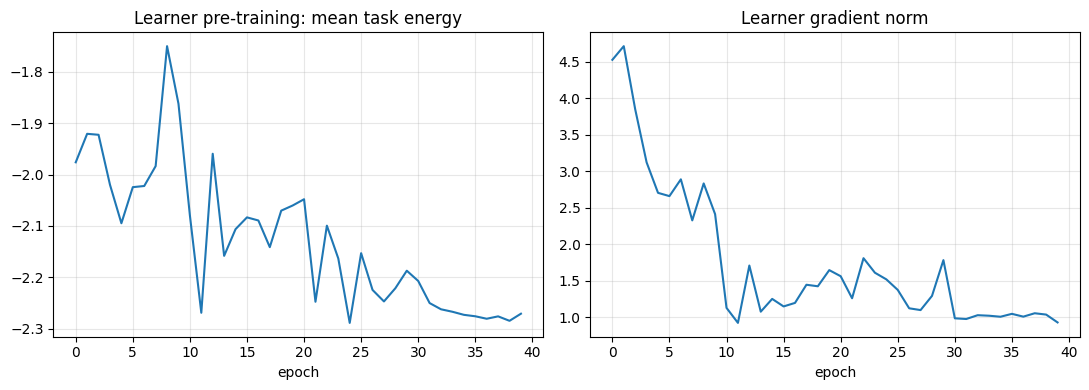

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_lmg(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = (DEPTH, NUM_QUBITS, 3)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((eps, V), E0) in enumerate(zip(test_tasks, test_E0)):
    H = lmg_hamiltonian(eps, V)
    print(f"task {ti}: epsilon={eps:.3f} V={V:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([eps, V], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_lmg(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: epsilon=1.282 V=-0.655  E0=-2.3534


task 1: epsilon=1.406 V=0.761  E0=-2.6300


task 2: epsilon=1.206 V=0.155  E0=-1.8391


task 3: epsilon=0.805 V=1.091  E0=-2.4566


task 4: epsilon=1.293 V=0.916  E0=-2.6935


task 5: epsilon=0.787 V=-0.755  E0=-1.9191


saved


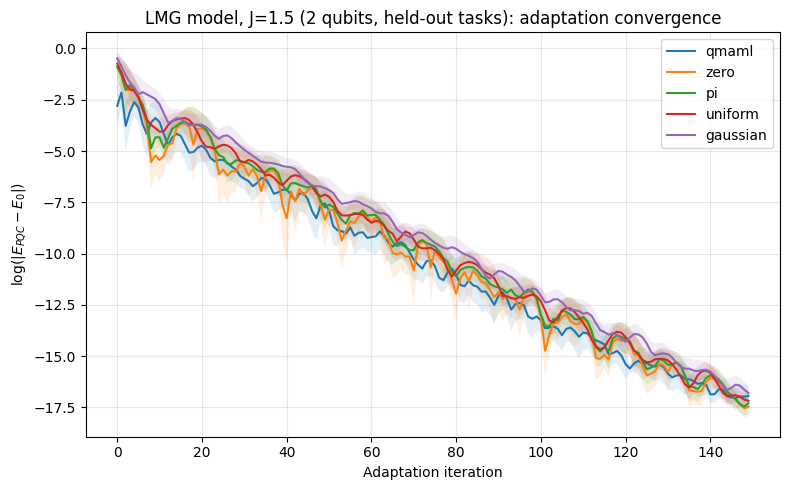

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-16.937   ~relative energy error=0.00%
  zero       log-gap=-17.462   ~relative energy error=0.00%
  pi         log-gap=-17.293   ~relative energy error=0.00%
  uniform    log-gap=-17.176   ~relative energy error=0.00%
  gaussian   log-gap=-16.796   ~relative energy error=0.00%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x_ax = np.arange(ADAPT_ITERS)
    ax.plot(x_ax, mean, label=scheme)
    ax.fill_between(x_ax, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"LMG model, J={J_SPIN} ({NUM_QUBITS} qubits, held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 4. Findings

**Run:** J=3/2 (2 qubits, 4 states), depth 3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 150 adaptation iterations, single seed.

- **No scheme wins here -- a genuine null result, not a close call dressed up as one.** Final log-gap: `zero` -17.462, `pi` -17.293, `uniform` -17.176, `qmaml` -16.937, `gaussian` -16.796 -- all five schemes reach the float64 precision floor (~0.00% relative error), and the ranking among them (`zero` nominally best, `qmaml` fourth of five) is well within run-to-run noise, not a meaningful ordering. The convergence plot (above) shows all five trajectories running together in a single noisy bundle for the *entire* 150-iteration budget, never meaningfully separating at any point -- unlike every other track in this project, where at least one scheme (usually `zero` or `pi`) visibly diverges from the pack somewhere in the trajectory.
- **The likely reason: the benchmark is too small to be informative.** J=3/2 gives a 4-dimensional Hilbert space on 2 qubits -- there simply may not be enough room for a bad initialization to get meaningfully stuck, or for a good one to meaningfully help, at this scale. This is a useful negative result in its own right: it suggests Track J would need a larger J (more qubits) before an initialization-scheme comparison here says anything beyond "everything works eventually on a small enough system" -- consistent with the source paper's own point that HL-VQE's advantage is about *scaling* efficiently to larger effective model spaces, not about the smallest cases being hard.
- **No comparison against HL-VQE's own reported energies was attempted** (their specific numeric results were not fetched for this pass -- see `lmg_qmaml.py`'s docstring), and this track does not reimplement their orbital-rotation Hamiltonian-learning step. Given the null result at this scale, a literal HL-VQE comparison would need a larger J anyway to be a meaningful test of either method.
- **MVP vs. full plan:** J=3/2 only (2 qubits), single seed. The clear next step, unlike most other tracks' "add more seeds" default, is **larger J** (more qubits) -- this benchmark needs to get harder before an initialization-scheme comparison here can say anything. Multi-seed replication of the current (uninformative) result would not add much; scaling up is the higher-value follow-up.
